

This notebook loads `best_random_forest_10b_indices.pkl` and runs inference on `test_data` without retraining.

Feature contract is aligned with the random_forest_train_10b_indices training setup:
- Spectral subset: `B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12`
- Spectral indices: `NDVI,NDBI,MNDWI`
- Same normalization rule used in training (`/10000` when needed, then clip to `[0,1]`)

In [ ]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

PROJECT_DIR = Path(r'c:/satellite/project')
TEST_DATA_DIR = PROJECT_DIR / 'data/test_data'
MODEL_PATH = PROJECT_DIR / 'best_random_forest_10b_indices.pkl'

DEFAULT_CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS = {1: 'darkgreen', 2: 'gold', 3: 'navy', 4: 'gray'}
EPS = 1e-6


POSTPROCESS_ENABLE = True
POSTPROCESS_WINDOW = 9

with open(MODEL_PATH, 'rb') as f:
    model_payload = pickle.load(f)

model = model_payload['model']
model_type = model_payload.get('model_type', type(model).__name__)
model_feature_names = model_payload['feature_names']
CLASS_NAMES = model_payload.get('class_names', DEFAULT_CLASS_NAMES)

CLASS_NAMES = {k: v for k, v in CLASS_NAMES.items() if k != 0}
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS

spectral_files = sorted(TEST_DATA_DIR.glob('*_Spectral*.tif'))
mask_files = sorted(TEST_DATA_DIR.glob('*_Mask*.tif'))

def pair_id(path: Path) -> str:
    name = path.name
    name = name.replace('_Spectral_12B.tif', '')
    name = name.replace('_Spectral.tif', '')
    name = name.replace('_Mask_Class.tif', '')
    name = name.replace('_Mask.tif', '')
    return name

spectral_lookup = {pair_id(path): path for path in spectral_files}
mask_lookup = {pair_id(path): path for path in mask_files}
common_ids = sorted(set(spectral_lookup) & set(mask_lookup))
sample_pairs = [
    {
        'name': site_id,
        'spectral_path': spectral_lookup[site_id],
        'mask_path': mask_lookup[site_id],
    }
    for site_id in common_ids
]

print(f'Model path: {MODEL_PATH}')
print(f'Model type: {model_type}')
print(f'Test data directory: {TEST_DATA_DIR}')
print(f'Paired test samples: {[item["name"] for item in sample_pairs]}')
print(f'Classes: {CLASS_NAMES}')
print(f'Model feature count: {len(model_feature_names)}')
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')
print(f'Unmatched spectral files: {len(set(spectral_lookup) - set(mask_lookup))}')
print(f'Unmatched mask files: {len(set(mask_lookup) - set(spectral_lookup))}')

Model path: c:\satellite\project\best_random_forest_10b_indices.pkl
Model type: random_forest
Test data directory: c:\satellite\project\data\test_data
Paired test samples: ['CairoUniv', 'HawaraFayoum', 'IconicTower', 'KarnakLuxor', 'PhilaeAswan', 'SiwaOasis']
Classes: {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
Model feature count: 16
Postprocessing enabled: False | window=9
Unmatched spectral files: 0
Unmatched mask files: 0


In [14]:
sample_item = sample_pairs[0]
sample_name = sample_item['name']
sample_spectral_path = sample_item['spectral_path']
sample_mask_path = sample_item['mask_path']

with rasterio.open(sample_spectral_path) as src:
    sample_band_count = src.count
    sample_shape = (src.count, src.height, src.width)
    sample_dtype = src.dtypes[0]
    sample_descriptions = src.descriptions

with rasterio.open(sample_mask_path) as src:
    sample_mask = src.read(1)
    sample_mask_values = np.unique(sample_mask)

print(f'Sample: {sample_name}')
print(f'Spectral shape: {sample_shape} | dtype={sample_dtype}')
print(f'Spectral band count: {sample_band_count}')
print(f'Band descriptions: {sample_descriptions}')
print(f'Mask unique values: {sample_mask_values.tolist()}')
assert sample_band_count == 12, f'Expected 12-band test_data imagery, got {sample_band_count} bands.'

Sample: CairoUniv
Spectral shape: (12, 256, 256) | dtype=float64
Spectral band count: 12
Band descriptions: (None, None, None, None, None, None, None, None, None, None, None, None)
Mask unique values: [1, 2, 3, 4]


In [15]:
IDX_B2 = 1
IDX_B3 = 2
IDX_B4 = 3
IDX_B5 = 4
IDX_B6 = 5
IDX_B7 = 6
IDX_B8 = 7
IDX_B8A = 8
IDX_B11 = 10
IDX_B12 = 11

SPECTRAL_10_NAMES = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
IDX10_B2 = SPECTRAL_10_NAMES.index('B2')
IDX10_B3 = SPECTRAL_10_NAMES.index('B3')
IDX10_B4 = SPECTRAL_10_NAMES.index('B4')
IDX10_B8 = SPECTRAL_10_NAMES.index('B8')
IDX10_B8A = SPECTRAL_10_NAMES.index('B8A')
IDX10_B11 = SPECTRAL_10_NAMES.index('B11')

INFER_FEATURE_NAMES = SPECTRAL_10_NAMES + ['NDVI', 'NDBI', 'MNDWI', 'BSI', 'DBI', 'NSI']

def normalize_spectral_10(spectral_cube: np.ndarray) -> np.ndarray:
    if spectral_cube.shape[0] == 10:
        spectral_raw = np.stack(spectral_cube, axis=0)
    else:
        spectral_raw = np.stack([
            spectral_cube[IDX_B2].astype(np.float32),
            spectral_cube[IDX_B3].astype(np.float32),
            spectral_cube[IDX_B4].astype(np.float32),
            spectral_cube[IDX_B5].astype(np.float32),
            spectral_cube[IDX_B6].astype(np.float32),
            spectral_cube[IDX_B7].astype(np.float32),
            spectral_cube[IDX_B8].astype(np.float32),
            spectral_cube[IDX_B8A].astype(np.float32),
            spectral_cube[IDX_B11].astype(np.float32),
            spectral_cube[IDX_B12].astype(np.float32),
        ], axis=0)
    spectral_scale_probe = np.nanpercentile(spectral_raw, 99)
    if spectral_scale_probe > 2.0:
        spectral_norm = np.clip(spectral_raw / 10000.0, 0.0, 1.0)
    else:
        spectral_norm = np.clip(spectral_raw, 0.0, 1.0)
    return spectral_norm

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    b2 = spectral_norm[IDX10_B2]
    b3 = spectral_norm[IDX10_B3]
    b4 = spectral_norm[IDX10_B4]
    b8 = spectral_norm[IDX10_B8]
    b8a = spectral_norm[IDX10_B8A]
    b11 = spectral_norm[IDX10_B11]
    ndvi  = (b8  - b4)  / (b8  + b4  + EPS)
    ndbi  = (b11 - b8)  / (b11 + b8  + EPS)
    mndwi = (b3  - b11) / (b3  + b11 + EPS)
    bsi   = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi   = ndbi - ndvi                            
    nsi   = (b11 - b8a) / (b11 + b8a + EPS)       
    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi], axis=0).astype(np.float32)

def build_inference_features(spectral_cube: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10(spectral_cube)

    
    spectral_flat = np.moveaxis(spectral_norm, 0, -1).reshape(-1, 10)

    
    index_maps = compute_spectral_indices(spectral_norm)
    index_flat = np.moveaxis(index_maps, 0, -1).reshape(-1, 6)

    return np.concatenate([spectral_flat, index_flat], axis=1).astype(np.float32)

print('Inference feature count:', len(INFER_FEATURE_NAMES))
print('Matches saved model feature contract:', INFER_FEATURE_NAMES == model_feature_names)
assert INFER_FEATURE_NAMES == model_feature_names, 'Inference features do not match the saved model feature order.'

Inference feature count: 16
Matches saved model feature contract: True


In [16]:
def compute_per_class_iou(y_true: np.ndarray, y_pred: np.ndarray, class_ids):
    ious = {}
    for class_id in class_ids:
        intersection = np.sum((y_true == class_id) & (y_pred == class_id))
        union = np.sum((y_true == class_id) | (y_pred == class_id))
        ious[class_id] = intersection / union if union > 0 else np.nan
    return ious

def majority_vote_smoothing(label_map: np.ndarray, class_ids, window: int = 3) -> np.ndarray:
    if window <= 1:
        return label_map
    if window % 2 == 0:
        raise ValueError('POSTPROCESS_WINDOW must be odd for centered voting.')

    pad = window // 2
    padded = np.pad(label_map, ((pad, pad), (pad, pad)), mode='reflect')
    patches = np.lib.stride_tricks.sliding_window_view(padded, (window, window))

    class_ids = np.array(class_ids, dtype=np.int32)
    vote_counts = np.stack([
        np.sum(patches == class_id, axis=(-1, -2))
        for class_id in class_ids
    ], axis=-1)

    winners = np.argmax(vote_counts, axis=-1)
    return class_ids[winners].astype(label_map.dtype)

def make_rgb(spectral_cube: np.ndarray) -> np.ndarray:
    red = spectral_cube[IDX_B4].astype(np.float32)
    green = spectral_cube[IDX_B3].astype(np.float32)
    blue = spectral_cube[IDX_B2].astype(np.float32)
    rgb = np.stack([red, green, blue], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    return np.clip((rgb - p2) / (p98 - p2 + EPS), 0, 1)

cmap_cls = ListedColormap([CLASS_COLORS[c] for c in CLASS_IDS])
bounds = np.arange(min(CLASS_IDS) - 0.5, max(CLASS_IDS) + 1.5, 1)
norm_cls = BoundaryNorm(bounds, ncolors=len(CLASS_IDS))
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}') for c in CLASS_IDS]

In [17]:
records = []
predictions_by_site = {}

for sample_item in sample_pairs:
    sample_name = sample_item['name']
    spectral_path = sample_item['spectral_path']
    mask_path = sample_item['mask_path']

    with rasterio.open(spectral_path) as src:
        spectral_cube = src.read().astype(np.float32)

    with rasterio.open(mask_path) as src:
        y_true = src.read(1).astype(np.int32)

    features = build_inference_features(spectral_cube)
    y_pred_raw = model.predict(features).reshape(y_true.shape).astype(np.int32)

    if POSTPROCESS_ENABLE:
        y_pred = majority_vote_smoothing(y_pred_raw, CLASS_IDS, window=POSTPROCESS_WINDOW)
    else:
        y_pred = y_pred_raw

    
    
    valid_mask = (y_true != 0)
    
    
    
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    ious = compute_per_class_iou(y_true_valid, y_pred_valid, ACTIVE_CLASSES)
    miou = float(np.nanmean([ious[c] for c in ACTIVE_CLASSES]))
    accuracy = float(np.mean(y_true_valid == y_pred_valid))

    row = {
        'sample': sample_name,
        'accuracy': accuracy,
        'mIoU_active': miou
    }
    for class_id in ACTIVE_CLASSES:
        row[f'IoU_{CLASS_NAMES[class_id]}'] = ious[class_id]
    records.append(row)

    predictions_by_site[sample_name] = {
        'spectral_cube': spectral_cube,
        'y_true': y_true,           
        'y_true_valid': y_true_valid, 
        'y_pred_raw': y_pred_raw,
        'y_pred': y_pred,
        'y_pred_valid': y_pred_valid 
    }

metrics_df = pd.DataFrame(records).sort_values('mIoU_active', ascending=False).reset_index(drop=True)
metrics_df

,sample,accuracy,mIoU_active,IoU_Greenery,IoU_Sand,IoU_Water,IoU_Cement
0,HawaraFayoum,0.907798,0.580333,0.918388,0.864837,0.244012,0.294094
1,SiwaOasis,0.861359,0.522928,0.723682,0.845102,NaN,0.000000
2,KarnakLuxor,0.627961,0.511378,0.628473,0.487392,0.929648,0.000000
3,CairoUniv,0.694473,0.472912,0.347983,0.029745,0.855699,0.658222
4,PhilaeAswan,0.871332,0.463899,0.214912,0.742811,0.897871,0.000000
5,IconicTower,0.686783,0.253397,0.149690,0.679013,0.000000,0.184885


In [18]:
print('Mean active-class mIoU:', round(metrics_df['mIoU_active'].mean(), 4))
print('Mean accuracy:', round(metrics_df['accuracy'].mean(), 4))
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')
print('\nPer-sample metrics:')
for _, row in metrics_df.iterrows():
    print(f"{row['sample']:<15} mIoU={row['mIoU_active']:.4f}  acc={row['accuracy']:.4f}")

Mean active-class mIoU: 0.4675
Mean accuracy: 0.775
Postprocessing enabled: False | window=9

Per-sample metrics:
HawaraFayoum    mIoU=0.5803  acc=0.9078
SiwaOasis       mIoU=0.5229  acc=0.8614
KarnakLuxor     mIoU=0.5114  acc=0.6280
CairoUniv       mIoU=0.4729  acc=0.6945
PhilaeAswan     mIoU=0.4639  acc=0.8713
IconicTower     mIoU=0.2534  acc=0.6868


              precision    recall  f1-score   support

    Greenery       0.85      0.90      0.87    107022
        Sand       0.81      0.78      0.80    186720
       Water       0.93      0.95      0.94     54477
      Cement       0.55      0.55      0.55     82955

    accuracy                           0.79    431174
   macro avg       0.79      0.80      0.79    431174
weighted avg       0.79      0.79      0.79    431174



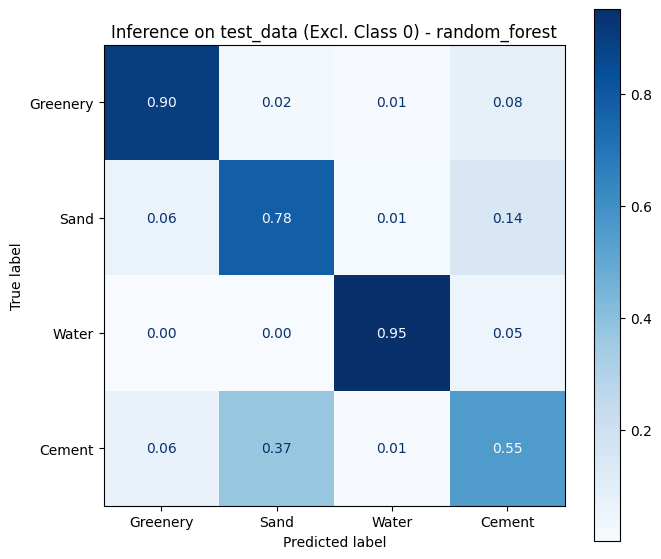

In [19]:

all_true = np.concatenate([predictions_by_site[item]['y_true_valid'] for item in predictions_by_site])
all_pred = np.concatenate([predictions_by_site[item]['y_pred_valid'] for item in predictions_by_site])

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]
).plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
ax.set_title(f'Inference on test_data (Excl. Class 0) - {model_type}')
plt.tight_layout()
plt.show()

In [20]:
print("Predictions:", np.unique(all_pred, return_counts=True))
print("Truth:", np.unique(all_true, return_counts=True))

Predictions: (array([1, 2, 3, 4], dtype=int32), array([113017, 178606,  55423,  84128]))
Truth: (array([1, 2, 3, 4], dtype=int32), array([107022, 186720,  54477,  82955]))


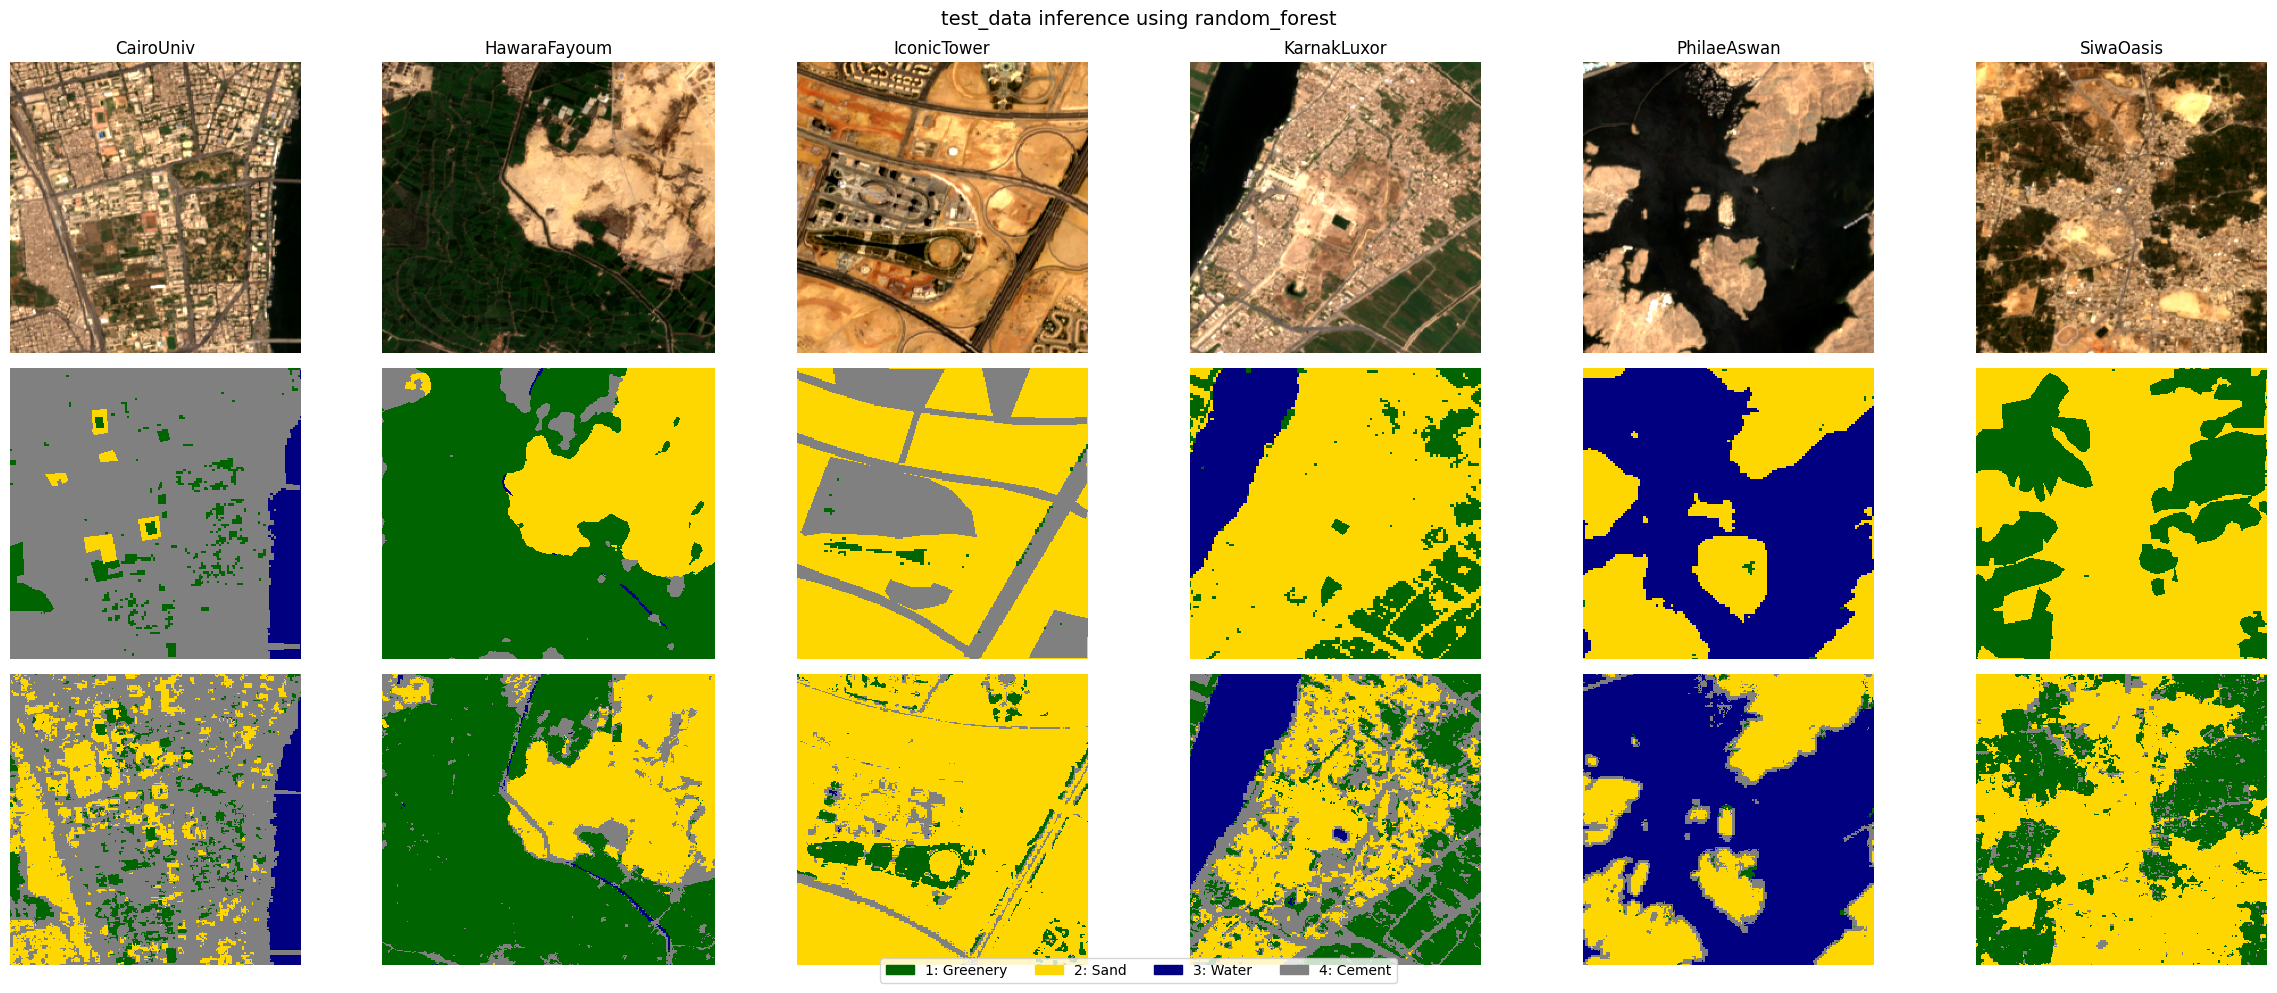

In [21]:
n_samples = len(sample_pairs)
n_rows = 4 if POSTPROCESS_ENABLE else 3
fig, axes = plt.subplots(n_rows, n_samples, figsize=(4 * n_samples, 3.3 * n_rows))

if n_samples == 1:
    axes = np.array(axes).reshape(n_rows, 1)

for col, sample_item in enumerate(sample_pairs):
    sample_name = sample_item['name']
    bundle = predictions_by_site[sample_name]
    rgb = make_rgb(bundle['spectral_cube'])

    axes[0, col].imshow(rgb)
    axes[0, col].set_title(sample_name)
    axes[0, col].axis('off')

    axes[1, col].imshow(bundle['y_true'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[1, col].axis('off')

    if POSTPROCESS_ENABLE:
        axes[2, col].imshow(bundle['y_pred_raw'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
        axes[2, col].axis('off')

        axes[3, col].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
        axes[3, col].axis('off')
    else:
        axes[2, col].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
        axes[2, col].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=10)
axes[1, 0].set_ylabel('Ground Truth', fontsize=10)
if POSTPROCESS_ENABLE:
    axes[2, 0].set_ylabel('Prediction (Raw)', fontsize=10)
    axes[3, 0].set_ylabel('Prediction (Smoothed)', fontsize=10)
else:
    axes[2, 0].set_ylabel('Prediction', fontsize=10)

fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_IDS), bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f'test_data inference using {model_type}', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
metrics_path = PROJECT_DIR / 'test_data_inference_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved metrics: {metrics_path}')

Saved metrics: c:\satellite\project\test_data_inference_metrics.csv
